In [100]:
import tensorflow as tf
import numpy as np
import pandas as pd
from pylab import rcParams
import matplotlib.pyplot as plt
import warnings
from mlxtend.plotting import plot_decision_regions
from matplotlib.colors import ListedColormap
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles
import seaborn as sns

In [113]:
X, y = make_circles(n_samples=1000, noise=0.1, random_state=1)

<Axes: >

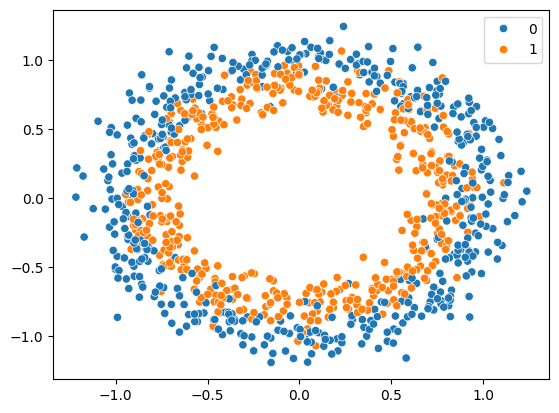

In [114]:
sns.scatterplot(x=X[:,0], y=X[:,1], hue=y)

In [115]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.10, random_state=2)

In [116]:
model = Sequential()

model.add(Dense(256, input_dim=2, activation='relu'))
model.add(Dense(512, activation='relu'))
model.add(Dense(1024, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

c:\Users\kusum\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [117]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [128]:
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=300, verbose=1)

Epoch 1/300
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8367 - loss: 0.3920 - val_accuracy: 0.9100 - val_loss: 0.3322
Epoch 2/300
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8378 - loss: 0.3914 - val_accuracy: 0.9100 - val_loss: 0.3313
Epoch 3/300
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8378 - loss: 0.3908 - val_accuracy: 0.9100 - val_loss: 0.3303
Epoch 4/300
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8378 - loss: 0.3902 - val_accuracy: 0.9100 - val_loss: 0.3294
Epoch 5/300
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8378 - loss: 0.3896 - val_accuracy: 0.9100 - val_loss: 0.3285
Epoch 6/300
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8378 - loss: 0.3891 - val_accuracy: 0.9100 - val_loss: 0.3277
Epoch 7/300
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8378 - loss: 0.3885 - val_accuracy: 0.9100 - val_loss: 0.3269
Epoch 8/300
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8378 - loss: 0.3880 - val_accuracy: 0.9100 - v

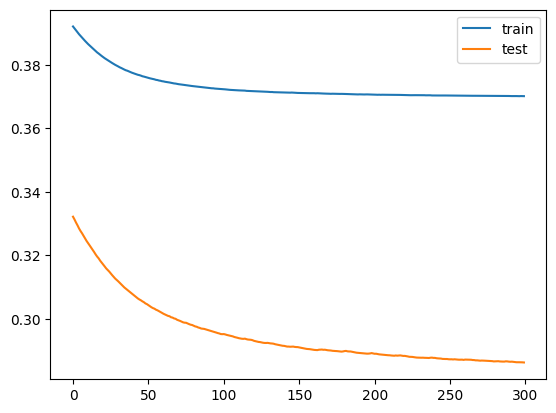

In [129]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show()

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 9s 969us/step


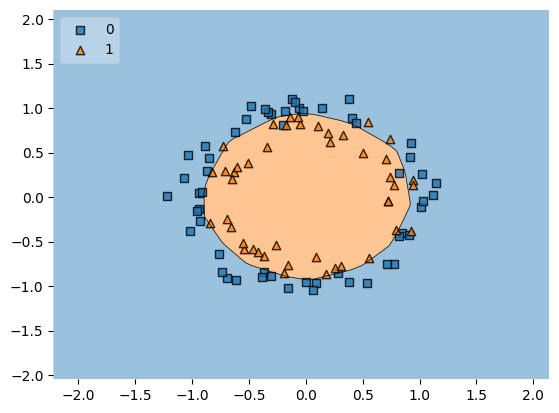

In [130]:
plot_decision_regions(X_test, y_test.ravel(), clf = model, legend=2)
plt.show()

In [131]:
# Early Stopping


In [132]:
model = Sequential()

model.add(Dense(256, input_dim=2, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

In [133]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [134]:
callback = EarlyStopping(
    monitor="val_loss",
    min_delta=0.00001,
    patience=20,
    verbose=1,
    mode="auto",
    baseline=None,
    restore_best_weights=False
)

In [135]:
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=3500, callbacks=callback)

Epoch 1/3500
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5000 - loss: 0.6912 - val_accuracy: 0.6000 - val_loss: 0.6823
Epoch 2/3500
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5133 - loss: 0.6854 - val_accuracy: 0.5600 - val_loss: 0.6814
Epoch 3/3500
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5322 - loss: 0.6815 - val_accuracy: 0.6000 - val_loss: 0.6781
Epoch 4/3500
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5833 - loss: 0.6770 - val_accuracy: 0.6300 - val_loss: 0.6737
Epoch 5/3500
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6278 - loss: 0.6720 - val_accuracy: 0.6900 - val_loss: 0.6686
Epoch 6/3500
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6622 - loss: 0.6663 - val_accuracy: 0.7300 - val_loss: 0.6627
Epoch 7/3500
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6889 - loss: 0.6598 - val_accuracy: 0.7500 - val_loss: 0.6560
Epoch 8/3500
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7167 - loss: 0.6528 - val_accuracy: 0

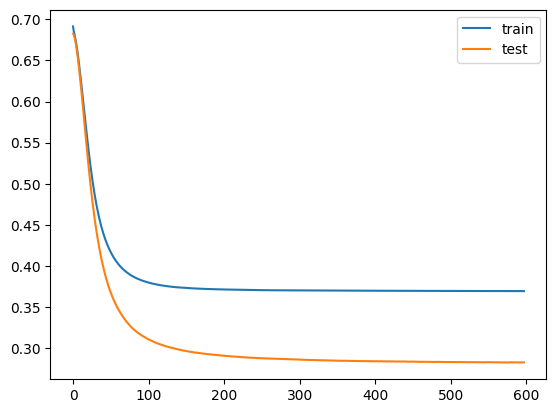

In [136]:

plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show()

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step


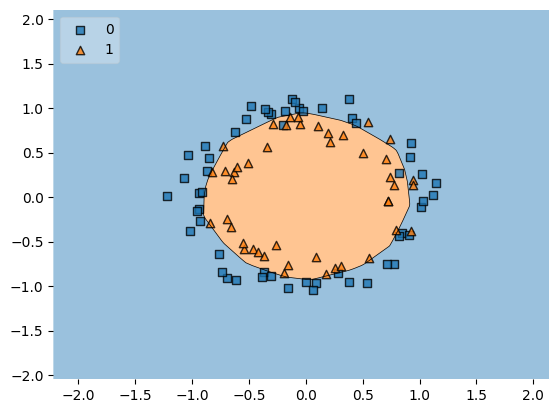

In [137]:
plot_decision_regions(X_test, y_test.ravel(), clf = model, legend=2)
plt.show()